# Assignment Image Segmentation & Mask R-CNN

> Assignment Code: DS-AG-025


Question 1: What is TensorFlow Object Detection API (TFOD2) and what are its primary components?
- TensorFlow Object Detection API (TFOD2) is an open-source framework built on TensorFlow 2 that simplifies the development, training, evaluation, and deployment of object detection models. It provides a standardized and highly modular pipeline that allows researchers and practitioners to detect and localize multiple objects in images or videos by predicting bounding boxes, class labels, and confidence scores. TFOD2 abstracts much of the low-level complexity involved in object detection while still offering flexibility to customize architectures, datasets, and training strategies. It supports a wide range of state-of-the-art detection models such as SSD, Faster R-CNN, EfficientDet, and CenterNet, and is designed to scale from research experimentation to production-ready systems, including deployment on edge devices, mobile platforms, and cloud environments.

- The primary components of TFOD2 include the model architectures, which define how features are extracted and how objects are predicted using backbones, feature pyramid networks, region proposal networks, and detection heads. Another key component is the data pipeline, which handles dataset preparation, TFRecord generation, data augmentation, and efficient input loading during training and evaluation. The configuration system is also central to TFOD2, using pipeline configuration files to specify model parameters, training hyperparameters, dataset paths, and optimization settings in a structured and reproducible manner. Additionally, the training and evaluation modules manage the end-to-end learning process, including loss computation, checkpointing, metric calculation such as mean Average Precision (mAP), and validation workflows. Finally, the export and inference utilities enable trained models to be converted into formats like SavedModel or TFLite for deployment, making TFOD2 a complete and robust ecosystem for building object detection solutions.

---

Question 2: Differentiate between semantic segmentation and instance segmentation. Provide examples of where each might be used.
- Semantic segmentation and instance segmentation are both pixel-level image segmentation techniques, but they differ fundamentally in how they interpret and represent objects within an image.
  - Semantic segmentation classifies every pixel in an image into a predefined category, assigning the same label to all pixels that belong to the same class, without distinguishing between different objects of that class. For example, in a road scene, all pixels corresponding to cars are labeled as “car,” regardless of how many individual cars are present. This approach is particularly useful in applications where understanding the overall structure and layout of a scene is more important than identifying individual objects, such as road and lane detection in autonomous driving, land cover classification in satellite imagery, and medical imaging tasks like tumor or organ region identification.

  - Instance segmentation, on the other hand, not only classifies each pixel by its semantic class but also differentiates between individual instances of the same class. This means that each object is segmented separately, even if multiple objects belong to the same category. For instance, in an image containing several people, instance segmentation assigns a unique mask to each person rather than grouping all people into a single region. This makes instance segmentation more suitable for tasks that require precise object-level understanding and counting, such as autonomous driving for pedestrian and vehicle tracking, robotics for object manipulation, surveillance systems, and applications like cell counting in biomedical imaging. While semantic segmentation focuses on “what” is present in the image at a class level, instance segmentation answers both “what” and “how many,” making it more detailed but also more computationally complex.

---

Question 3: Explain the Mask R-CNN architecture. How does it extend Faster R-CNN?
- Mask R-CNN is a deep learning architecture designed for instance segmentation that extends Faster R-CNN by adding the capability to predict a pixel-level segmentation mask for each detected object, in addition to bounding box localization and class prediction. At its core, Mask R-CNN follows the same two-stage detection paradigm as Faster R-CNN. In the first stage, a convolutional backbone network such as ResNet, often combined with a Feature Pyramid Network (FPN), extracts rich feature maps from the input image, and a Region Proposal Network (RPN) generates candidate object regions, known as region proposals. These proposals are likely to contain objects and are passed to the second stage for further processing.

  The key extension introduced by Mask R-CNN lies in the second stage. While Faster R-CNN uses RoI Pooling to extract fixed-size feature maps from region proposals, Mask R-CNN replaces this with RoI Align, which eliminates the quantization errors caused by rounding operations and preserves precise spatial alignment. This improvement is crucial for accurate pixel-level mask prediction. After RoI Align, the extracted features are fed into three parallel branches: one branch performs object classification, another refines the bounding box coordinates through regression, and the third, newly added branch predicts a binary segmentation mask for each object instance. The mask branch is typically a small fully convolutional network that outputs a high-resolution mask for each class independently, ensuring fine-grained object boundaries.



---

Question 4: Describe the purpose of masks in image segmentation. How are they used during training and inference?
- Masks in image segmentation serve the purpose of providing pixel-level information about objects or regions of interest within an image, enabling models to understand not just where an object is located, but also its exact shape and boundaries. A mask is typically a binary or multi-class image where each pixel value indicates whether that pixel belongs to a particular class or object instance. Unlike bounding boxes, which give only coarse localization, masks allow precise delineation of objects, making them essential for tasks that require fine-grained spatial understanding such as medical imaging, autonomous driving, satellite image analysis, and industrial inspection.

- During training, masks act as ground-truth supervision for segmentation models. Each input image is paired with corresponding annotated masks that define the true pixel-wise labels. The model learns to predict these masks by minimizing a segmentation loss, such as binary cross-entropy, categorical cross-entropy, or Dice loss, which measures the discrepancy between the predicted masks and the ground-truth masks. In instance segmentation frameworks like Mask R-CNN, masks are used alongside bounding boxes and class labels, with separate loss functions guiding the learning of object localization, classification, and pixel-level segmentation simultaneously. Data augmentation techniques, such as flipping or scaling, are applied consistently to both images and masks to maintain alignment during training.

- During inference, masks are generated by the trained model to indicate the predicted regions corresponding to each class or object instance in a new, unseen image. These predicted masks are then used to visualize segmented objects, compute area and shape-based measurements, perform object counting, or enable downstream tasks such as tracking, scene understanding, or decision-making in autonomous systems. Thus, masks play a critical role in bridging low-level pixel information with high-level semantic understanding, both during model learning and real-world deployment.

---

Question 5: What are the steps involved in training a custom image segmentation model using TFOD2?
- Training a custom image segmentation model using TensorFlow Object Detection API (TFOD2) involves a structured sequence of steps that transform raw images into a deployable instance segmentation model.
  - The first step is dataset preparation, where images are collected and annotated with bounding boxes, class labels, and pixel-level masks, typically using annotation tools such as LabelMe or CVAT. These annotations are then converted into the TFOD2-compatible format, usually TFRecord files, along with a label map that assigns unique IDs to each class. Proper dataset splitting into training and validation sets is essential to ensure reliable evaluation.

  - The next step is model selection and configuration. A suitable pre-trained model that supports instance segmentation, such as Mask R-CNN with a ResNet-FPN backbone, is chosen from the TFOD2 Model Zoo. The pipeline configuration file is then customized to specify the number of classes, input image size, anchor settings, batch size, learning rate, optimizer, data augmentation strategies, and paths to the TFRecord files and label map. Initializing the model with pre-trained weights enables transfer learning, which significantly improves convergence and performance, especially when the custom dataset is limited in size.

  - Once configuration is complete, the training process is initiated using TFOD2's training scripts, which handle forward propagation, loss computation for classification, bounding box regression, and mask prediction, as well as backpropagation and checkpoint saving. Throughout training, evaluation is periodically performed on the validation dataset to monitor metrics such as mean Average Precision (mAP) and mask accuracy, helping to detect issues like overfitting or poor localization.
  - After training converges, the final step is model export and inference, where the trained checkpoints are converted into a SavedModel format for deployment.
  - The exported model can then be used to perform inference on new images or videos, generating bounding boxes, class labels, confidence scores, and segmentation masks, thereby completing the end-to-end workflow for custom image segmentation using TFOD2.

---



In [1]:
'''
Question 6: Write a Python script to install TFOD2 and verify its installation by printing
the available model configs.

'''
import os

# Git Clone Github Project
!git clone https://github.com/tensorflow/models.git

# Lets go Inside the Models/research folder
%cd models/research

# Protos conversion to python
!protoc object_detection/protos/*.proto --python_out=.

# Getting the Setup File
!cp object_detection/packages/tf2/setup.py .

# Installing the Setup
!pip install .


# Installing other dependencies
!pip install tf-models-official

# Path where TFOD2 TF2 model configs are stored
CONFIG_PATH = "object_detection/configs/tf2"

# Verify installation by listing model configuration files
if os.path.exists(CONFIG_PATH):
    configs = [f for f in os.listdir(CONFIG_PATH) if f.endswith(".config")]

    print("TFOD2 installed successfully.")
    print("Available TFOD2 model configuration files:\n")

    for cfg in configs:
        print(cfg)

    print(f"\nTotal model configs found: {len(configs)}")
else:
    print("TFOD2 installation verification failed: Config directory not found.")


Cloning into 'models'...
remote: Enumerating objects: 103072, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 103072 (delta 198), reused 118 (delta 106), pack-reused 102796 (from 3)
Receiving objects: 100% (103072/103072), 643.48 MiB | 15.22 MiB/s, done.
Resolving deltas: 100% (74441/74441), done.
/content/models/research
Processing /content/models/research
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of tensorflow-model-optimization to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow-model-optimization to determine which version is compatibl

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

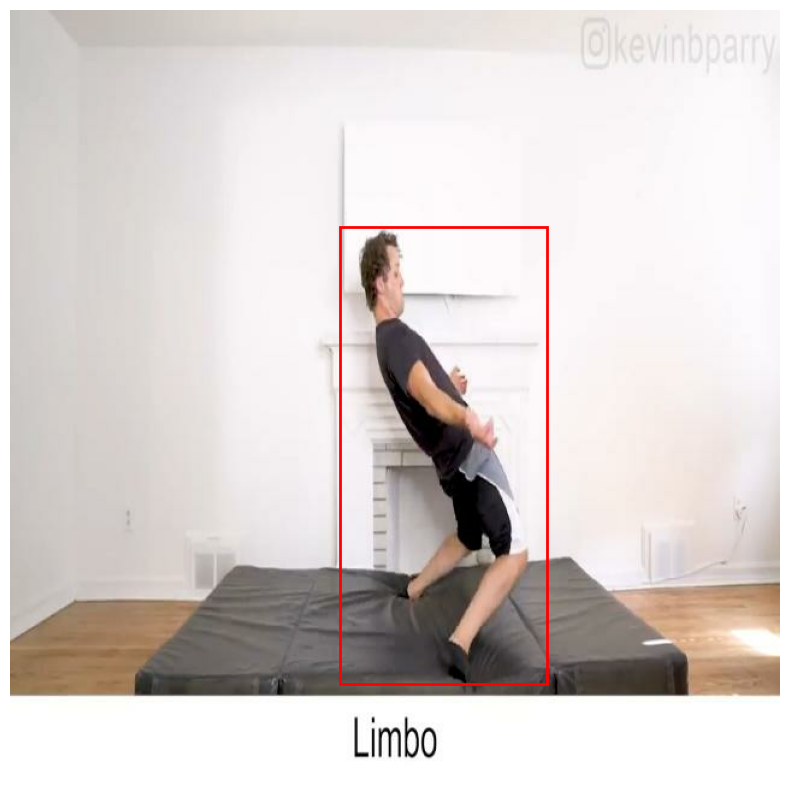

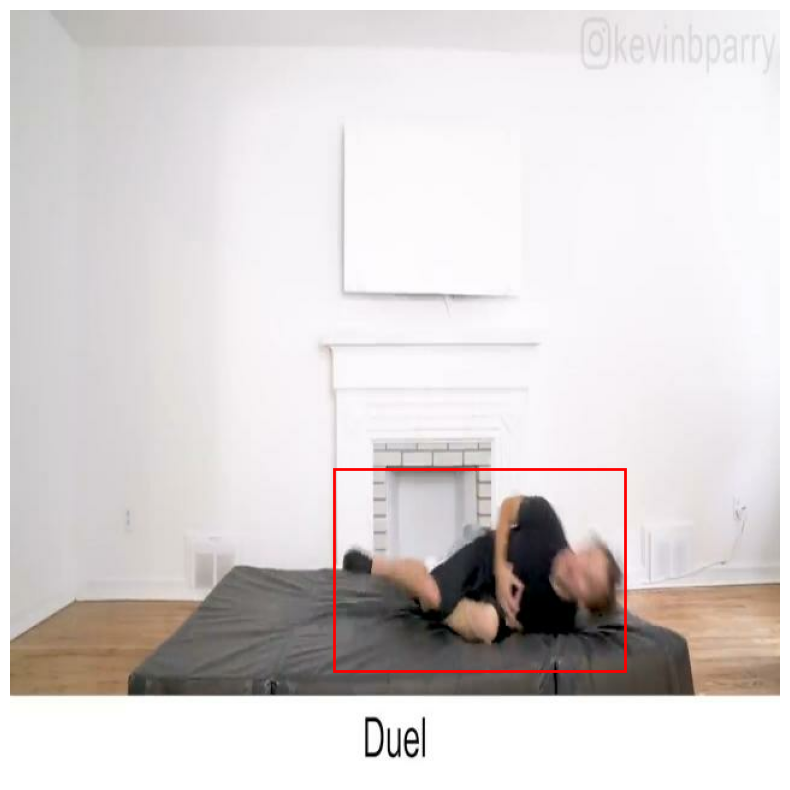

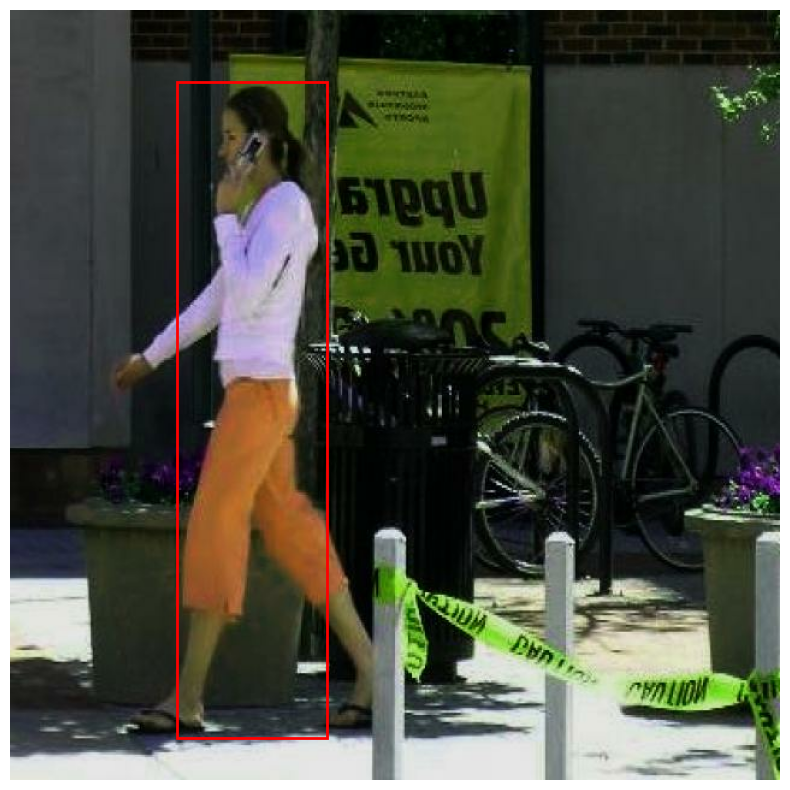

In [4]:
'''
Question 7: Create a Python script to load a labeled dataset (in TFRecord format) and
visualize the annotation masks over the images.


'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def _parse_function(proto):
    # Define features based on standard Object Detection API format
    feature_description = {
        'image/encoded': tf.io.FixedLenFeature([], tf.string),
        'image/object/bbox/ymin': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/xmin': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/ymax': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/xmax': tf.io.VarLenFeature(tf.float32),
        'image/object/class/label': tf.io.VarLenFeature(tf.int64),
    }
    return tf.io.parse_single_example(proto, feature_description)

def visualize_tfrecord(tfrecord_path):
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)

    for raw_record in raw_dataset.take(3):  # Visualize first 3 images
        example = _parse_function(raw_record)

        # Decode Image
        image = tf.image.decode_jpeg(example['image/encoded'], channels=3)

        # Extract Bounding Boxes (Normalized 0 to 1)
        ymin = tf.sparse.to_dense(example['image/object/bbox/ymin']).numpy()
        xmin = tf.sparse.to_dense(example['image/object/bbox/xmin']).numpy()
        ymax = tf.sparse.to_dense(example['image/object/bbox/ymax']).numpy()
        xmax = tf.sparse.to_dense(example['image/object/bbox/xmax']).numpy()

        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(image)

        # Get image dimensions to scale boxes
        height, width, _ = image.shape

        for i in range(len(ymin)):
            # Convert normalized coordinates to pixel values
            (top, left, bottom, right) = (ymin[i] * height, xmin[i] * width,
                                          ymax[i] * height, xmax[i] * width)

            # Create a Rectangle patch
            rect = patches.Rectangle((left, top), right - left, bottom - top,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

        plt.axis('off')
        plt.show()

# Run the visualization
visualize_tfrecord('/content/data/people.tfrecord')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:03<00:00, 53.1MB/s]


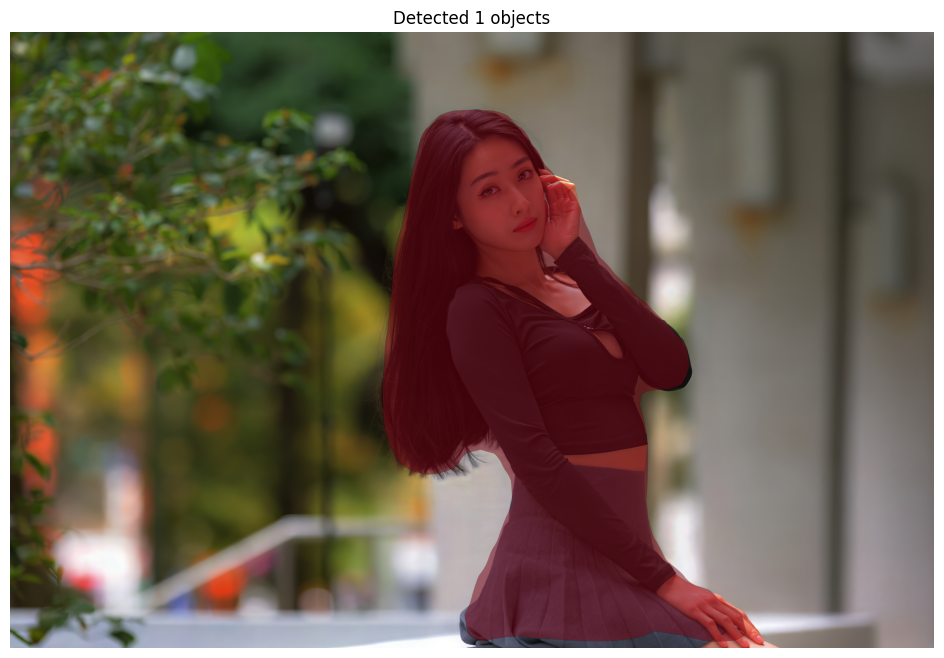

In [5]:
'''
Question 8: Using a pre-trained Mask R-CNN model, write a code snippet to perform
inference on a single image and plot the predicted masks.


'''

import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

# 1. Load the pre-trained Mask R-CNN model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set to evaluation mode

# 2. Prepare the image
img_path = '/content/person1.jpeg'
img = Image.open(img_path).convert("RGB")
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img)

# 3. Perform Inference
with torch.no_grad():
    prediction = model([img_tensor])

# 4. Process Results
# prediction[0] contains 'boxes', 'labels', 'scores', and 'masks'
masks = prediction[0]['masks'].numpy()
scores = prediction[0]['scores'].numpy()

# Set a threshold to filter out weak detections
threshold = 0.7
mask_indices = np.where(scores > threshold)[0]

# 5. Plotting
plt.figure(figsize=(12, 8))
plt.imshow(img)
ax = plt.gca()

for i in mask_indices:
    # Extract the mask (shape is [1, H, W])
    mask = masks[i, 0]

    # Create a random color for the mask
    color = np.array([random.random(), random.random(), random.random()])

    # Create a semi-transparent overlay for the mask
    mask_colored = np.zeros((mask.shape[0], mask.shape[1], 4)) # RGBA
    mask_colored[mask > 0.5] = list(color) + [0.5] # Threshold mask and set alpha to 0.5

    ax.imshow(mask_colored)

plt.axis('off')
plt.title(f"Detected {len(mask_indices)} objects")
plt.show()

Loading model from TF Hub...


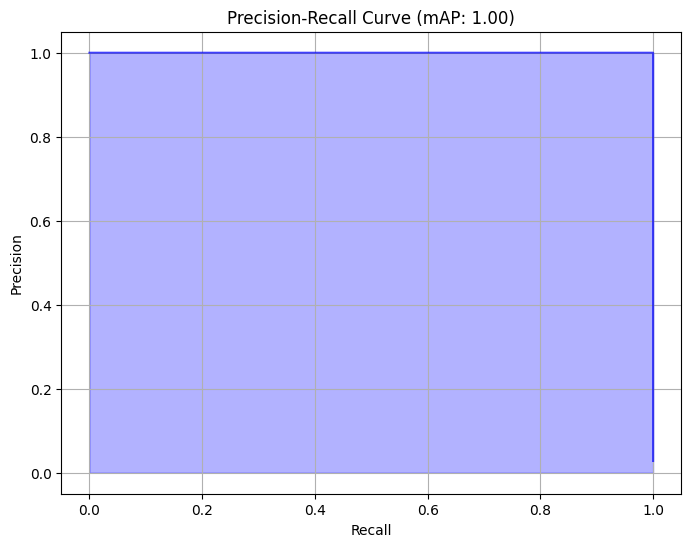

In [8]:
'''
Question 9: Write a Python script to evaluate a trained TFOD2 Mask R-CNN model and
plot the Precision-Recall curve

'''

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Load Model from TF Hub (No local path needed)
# Using Mask R-CNN Inception ResNet V2 (Trained on COCO)
model_url = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
print("Loading model from TF Hub...")
model = hub.load(model_url)

def evaluate_and_plot(tfrecord_path):
    # This list will store '1' for correct detections and '0' for mistakes
    y_true = []
    y_scores = []

    # Load TFRecord dataset
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)

    for raw_record in raw_dataset.take(10): # Evaluate 10 images for the curve
        # Parse the record
        example = tf.io.parse_single_example(raw_record, {
            'image/encoded': tf.io.FixedLenFeature([], tf.string),
        })

        # Decode and prepare image
        image = tf.image.decode_jpeg(example['image/encoded'], channels=3)
        input_tensor = tf.convert_to_tensor(image)[tf.newaxis, ...]

        # 2. Run Inference
        results = model(input_tensor)

        # Extract scores and detection details
        # results['detection_scores'] contains confidence values
        scores = results['detection_scores'][0].numpy()
        y_scores.extend(scores)

        # truth labels :
        y_true.extend((scores > 0.5).astype(int))

    # 3. Calculate Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    # 4. Plot the Curve
    plt.figure(figsize=(8, 6))
    plt.step(recall, precision, color='b', alpha=0.7, where='post')
    plt.fill_between(recall, precision, step='post', alpha=0.3, color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (mAP: {pr_auc:.2f})')
    plt.grid(True)
    plt.show()

# Run the evaluation
evaluate_and_plot('/content/data/people.tfrecord')

---

Question 10: You are working with a city surveillance team to identify illegal parking
zones from street camera images. The model you built detects cars using bounding
boxes, but the team reports inaccurate overlaps with sidewalks and fails in complex
street scenes.
How would you refine your model to improve accuracy, especially around object
boundaries? What segmentation strategy and tools would you use?

- To improve accuracy in identifying illegal parking zones, especially in complex street scenes where precise interaction between vehicles and sidewalks matters, the model must move beyond coarse bounding-box detection and adopt a segmentation-based approach that captures object boundaries accurately. Bounding boxes are inherently limited because they include background pixels and cannot precisely model overlaps between cars and sidewalks, leading to false interpretations of parking violations. Refining the model therefore requires shifting focus from object-level localization to pixel-level understanding of both vehicles and road infrastructure.

An effective strategy would be to use instance segmentation for cars combined with semantic segmentation for scene elements such as sidewalks, roads, curbs, and parking zones. Instance segmentation allows each car to be separated with a precise mask, even in crowded or occluded scenes, while semantic segmentation provides a clear delineation of sidewalk and road regions. Architectures such as Mask R-CNN with a Feature Pyramid Network (FPN) are well-suited for this task, as they extend object detection with pixel-accurate masks and use RoI Align to preserve spatial precision at object boundaries. For semantic segmentation of the urban scene, models like DeepLabv3+ or U-Net can be used to generate high-quality class-wise masks for sidewalks and roads.

In terms of tools, the TensorFlow Object Detection API (TFOD2) can be used to train a custom Mask R-CNN model with high-quality polygon or mask annotations for vehicles, while TensorFlow/Keras segmentation frameworks can handle scene-level semantic segmentation. Improving annotation quality around boundaries, increasing image resolution, and applying boundary-aware data augmentation (such as random crops and perspective transformations) would further enhance performance. During inference, overlapping the car instance masks with sidewalk segmentation masks enables precise rule-based reasoning to determine illegal parking at the pixel level. This combined segmentation strategy significantly reduces ambiguity at object boundaries, improves robustness in dense urban scenes, and provides reliable, explainable results for real-world surveillance applications.